# ABF and ABF+FR for a dimer in a WCA solvent

Classical dimer-in-solvent example from *Free Energy Computations: A Mathematical Perspective*, Section 5.1.5, Section 1.3.2.4, and Section 2.5.2.3.

This is the **full GPU / PyTorch** notebook (production scale). It develops the
theory and then compares two methods,

1. **ABF** — standard adaptive biasing force;
2. **ABF+FR** — ABF plus a Fisher--Rao birth--death step that uses a *reference-target*
   density $\widehat q_n(z)\propto\exp[-\beta(F_{\mathrm{target}}(z)-B_n(z))]$,

against a thermodynamic-integration (TI) reference. The scientific goal is
**free-energy accuracy**, reported as the L2 errors of the mean force
$\widehat A_n'(z)$ and the integrated free energy $\widehat A_n(z)$ against the TI
reference — these two L2 errors are the only metrics we track.

## Background

We simulate $N$ particles in a two-dimensional periodic square box. A configuration is

$$
q = (q_1,\ldots,q_N), \qquad q_i \in \mathbb{R}^2.
$$

Particles $q_1$ and $q_2$ are the dimer. Particles $q_3,\ldots,q_N$ are the WCA solvent.

### Potential
The WCA potential is a truncated and shifted Lennard-Jones repulsion:
$$
V_{\rm WCA}(r)=
\begin{cases}
4\varepsilon\left[\left(\frac{\sigma}{r}\right)^{12}
-\left(\frac{\sigma}{r}\right)^6\right]+\varepsilon,
& r\le r_0,\\
0,& r>r_0,
\end{cases}
$$
where $r_0 = 2^{1/6}\sigma$.

The interaction between two dimers is the double-well bond potential
$$
V_S(r)=h\left[1-\frac{(r-r_0-w)^2}{w^2}\right]^2,
$$
which has minima at $r=r_0$ and $r=r_0+2w$, corresponding to $z=0$ and $z=1$, and a barrier of height $h$ at $r=r_0+w$, corresponding to $z=1/2$.

The total potential is given by
$$
V(q) = V_S(|q_1 - q_2|) + \sum_{3 \leq i < j \leq N} V_{\rm WCA} (|q_i - q_j|) + \sum_{i = 1, 2} \sum_{3 \leq j \leq N} V_{\rm WCA} (|q_i - q_j|).
$$

### Reaction coordinate
The reaction coordinate is
$$
\xi(q) = \frac{|q_1-q_2|-r_0}{2w}.
$$
With this normalization, $\xi=0$ is the compact well and $\xi=1$ is the stretched well.

### Constrained sampling space
We put the particles in a square box following the setup in the numerical experiments in `WCA_dimer`. The square box has side length $L = n_{\rm dim} a$ where the initial solvent positions lie on an $n_{\rm dim}\times n_{\rm dim}$ lattice with spacing $a$.

Periodic boundary conditions mean that positions are stored modulo $L$. Distances use the **minimum-image convention**: for a displacement $d$, replace it by $d - L\,\mathrm{round}(d/L)$ so each component lies in $[-L/2,L/2]$.

## GPU implementation

This notebook keeps all simulation arrays as `torch.Tensor`s on the GPU. Compared
with a dense NumPy implementation it:

- uses precomputed pair indices instead of full `(N,N)` pair matrices;
- avoids autograd and runs under `torch.inference_mode()`;
- batches all replicas in parallel and batches thermodynamic integration over
  chunks of reaction-coordinate values;
- transfers data back to the CPU only for the final error diagnostics.

It is designed for an H100/G4-class GPU. In Colab, use
**Runtime -> Change runtime type -> GPU** before running.

In [1]:
import math
import time
from dataclasses import dataclass, replace

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

print("torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("WARNING: CUDA is not available. In Colab, set Runtime -> Change runtime type -> GPU.")

# Use CUDA in Colab. Fallbacks are only for local syntax/smoke testing.
def choose_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")

DEVICE = choose_device()
DTYPE = torch.float32
EPS = 1.0e-12

if DEVICE.type == "cuda":
    # Useful for Ampere/Lovelace GPUs. This notebook does not use matrix multiply
    # heavily, but enabling TF32 is harmless for ancillary kernels.
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

print("device:", DEVICE)

torch: 2.11.0+cu128
CUDA available: True
GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition
device: cuda


## Configuration

The default `SimConfig` is a production-oriented setting for a G4/moderate GPU
(512 replicas, 200k steps). An optional high-accuracy `sim_h100` block is provided
for H100-class GPUs but is **not** used unless `RUN_H100_PRODUCTION = True`.

The Fisher--Rao target for ABF+FR uses the TI reference free energy, so
`RUN_TI_REFERENCE` must produce (or a prior session must provide) a `ti_reference`
before the main simulation runs. The benchmark cell estimates runtime on the actual
GPU before you commit to the full run.

In [2]:
@dataclass(frozen=True)
class DimerWCAParams:
    n_dim: int = 10
    a: float = 1.5
    sigma: float = 1.0
    epsilon: float = 1.0
    h: float = 2.0
    w: float = 2.0
    beta: float = 1.0
    min_r: float = 0.65
    force_clip: float = 250.0

    @property
    def n_particles(self):
        return self.n_dim * self.n_dim

    @property
    def box_length(self):
        return self.n_dim * self.a

    @property
    def r0(self):
        return 2.0 ** (1.0 / 6.0) * self.sigma

    @property
    def wca_cutoff(self):
        return self.r0


@dataclass(frozen=True)
class SimConfig:
    n_replicas: int = 512
    dt: float = 2.0e-3
    n_steps: int = 200_000
    save_every: int = 2000
    seed: int = 42

    z_min: float = -0.2
    z_max: float = 1.2
    n_grid: int = 160

    abf_bandwidth: float = 0.025
    kde_bandwidth: float = 0.070
    abf_smooth_sigma: float = 0.50

    mean_force_sample_clip: float = 500.0
    use_clipped_force_for_mean_force: bool = True
    # Scale applied to the ABF bias in the force step. The Fisher-Rao target uses
    # the same scale, so B_n(z) = abf_bias_scale * ramp_n * A_n(z).
    abf_bias_scale: float = 1.0
    abf_edge_extrapolate: bool = True
    boundary_wall_strength: float = 80.0
    abf_force_clip: float = 40.0
    abf_warmup_steps: int = 10_000
    estimator_burn_in_steps: int = 10_000

    # Tuned on this GPU at full scale (see the Fisher-Rao sweep cell): the
    # free-energy gain over ABF is largest with GENTLE selection (fr_rate~0.2,
    # ~+48%) and falls monotonically as fr_rate grows, because aggressive
    # birth-death erodes the replica diversity the mean-force estimator needs.
    fr_rate: float = 0.2
    score_clip: float = 2.0
    fr_start_steps: int = 20_000
    fr_every: int = 5
    n_trace: int = 10
    marginal_burn_in_steps: int = 20_000

    barrier_center: float = 0.5
    transition_half_width: float = 0.15


@dataclass(frozen=True)
class TIConfig:
    z_min: float = -0.2
    z_max: float = 1.2
    n_z: int = 51
    n_replicas: int = 128
    dt: float = 2.0e-3
    n_thermalization: int = 5_000
    n_steps: int = 50_000
    sample_every: int = 20
    seed: int = 314159
    smooth_sigma: float = 1.0

    # Number of z values processed simultaneously on the GPU. Increase this on
    # large-memory GPUs; decrease if Colab reports out-of-memory.
    z_chunk_size: int = 8


params = DimerWCAParams()
sim = SimConfig()

# Optional H100 / high-accuracy configuration. NOT used unless the flag below is
# set to True. Do not auto-run this; it is a long production setting.
RUN_H100_PRODUCTION = False
sim_h100 = replace(
    sim,
    n_replicas=1024,
    n_steps=400_000,
    save_every=4000,
    n_grid=200,
    fr_start_steps=40_000,
    fr_every=5,
    fr_rate=0.2,
    score_clip=2.0,
)
if RUN_H100_PRODUCTION:
    sim = sim_h100

ti = TIConfig(z_min=sim.z_min, z_max=sim.z_max, dt=sim.dt)

RUN_MAIN_SIMULATION = True
RUN_TI_REFERENCE = True
RUN_BENCHMARK = True
# Only ABF and ABF+FR (internal key "wfr_abf").
METHODS_TO_RUN = ("abf", "wfr_abf")

print(params)
print(sim)
print(ti)
print(f"N={params.n_particles}, L={params.box_length:.3f}, r0={params.r0:.6f}")
print(f"RUN_H100_PRODUCTION={RUN_H100_PRODUCTION} (active sim n_replicas={sim.n_replicas}, n_steps={sim.n_steps})")

DimerWCAParams(n_dim=10, a=1.5, sigma=1.0, epsilon=1.0, h=2.0, w=2.0, beta=1.0, min_r=0.65, force_clip=250.0)
SimConfig(n_replicas=512, dt=0.002, n_steps=200000, save_every=2000, seed=42, z_min=-0.2, z_max=1.2, n_grid=160, abf_bandwidth=0.025, kde_bandwidth=0.07, abf_smooth_sigma=0.5, mean_force_sample_clip=500.0, use_clipped_force_for_mean_force=True, abf_bias_scale=1.0, abf_edge_extrapolate=True, boundary_wall_strength=80.0, abf_force_clip=40.0, abf_warmup_steps=10000, estimator_burn_in_steps=10000, fr_rate=0.2, score_clip=2.0, fr_start_steps=20000, fr_every=5, n_trace=10, marginal_burn_in_steps=20000, barrier_center=0.5, transition_half_width=0.15)
TIConfig(z_min=-0.2, z_max=1.2, n_z=51, n_replicas=128, dt=0.002, n_thermalization=5000, n_steps=50000, sample_every=20, seed=314159, smooth_sigma=1.0, z_chunk_size=8)
N=100, L=15.000, r0=1.122462
RUN_H100_PRODUCTION=False (active sim n_replicas=512, n_steps=200000)


## Force engine

For WCA, only pair distances are needed. We precompute all unordered particle pairs except the dimer pair `(0,1)`. The force calculation then works on arrays of shape `(batch, n_pairs, 2)` instead of `(batch, N, N, 2)`. This reduces memory and avoids duplicate pair work.

The batch dimension represents independent replicas. In TI, it can represent several `z` values times several replicas per `z`.

In [3]:
def as_tensor(x, device=DEVICE, dtype=DTYPE):
    return torch.as_tensor(x, device=device, dtype=dtype)


def wrap_positions(q, L):
    return torch.remainder(q, L)


def minimum_image(delta, L):
    return delta - L * torch.round(delta / L)


def clip_forces(forces, force_clip):
    norm = torch.linalg.norm(forces, dim=-1, keepdim=True)
    scale = torch.clamp(force_clip / torch.clamp(norm, min=EPS), max=1.0)
    return forces * scale


class WCADimerEngine:
    """GPU pair-list force engine for the dimer in WCA solvent."""

    def __init__(self, params, device=DEVICE, dtype=DTYPE):
        self.params = params
        self.device = device
        self.dtype = dtype
        self.N = params.n_particles
        self.L = float(params.box_length)
        self.sigma = float(params.sigma)
        self.epsilon = float(params.epsilon)
        self.h = float(params.h)
        self.w = float(params.w)
        self.r0 = float(params.r0)
        self.cutoff = float(params.wca_cutoff)
        self.min_r = float(params.min_r)

        pair_i, pair_j = torch.triu_indices(self.N, self.N, offset=1, device=device)
        keep = ~((pair_i == 0) & (pair_j == 1))
        self.pair_i = pair_i[keep].long()
        self.pair_j = pair_j[keep].long()
        self.n_pairs = int(self.pair_i.numel())

    def force(self, q, compute_energy=False):
        """Return physical forces -grad V, optionally with total energy."""
        B = q.shape[0]
        qi = q.index_select(1, self.pair_i)
        qj = q.index_select(1, self.pair_j)
        delta = minimum_image(qi - qj, self.L)
        r = torch.linalg.norm(delta, dim=-1)
        r_safe = torch.clamp(r, min=self.min_r * self.sigma)

        active = r <= self.cutoff
        inv = self.sigma / r_safe
        inv6 = inv**6
        inv12 = inv6**2
        dVdr = 4.0 * self.epsilon * (-12.0 * inv12 / r_safe + 6.0 * inv6 / r_safe)
        dVdr = torch.where(active, dVdr, torch.zeros_like(dVdr))
        f_pair = (-dVdr / torch.clamp(r_safe, min=EPS)).unsqueeze(-1) * delta

        forces = torch.zeros_like(q)
        idx_i = self.pair_i.view(1, -1, 1).expand(B, -1, 2)
        idx_j = self.pair_j.view(1, -1, 1).expand(B, -1, 2)
        forces.scatter_add_(1, idx_i, f_pair)
        forces.scatter_add_(1, idx_j, -f_pair)

        d01 = minimum_image(q[:, 0, :] - q[:, 1, :], self.L)
        r01 = torch.linalg.norm(d01, dim=1).clamp_min(EPS)
        u = (r01 - self.r0 - self.w) / self.w
        dVdr_dim = -4.0 * self.h * u * (1.0 - u**2) / self.w
        f01 = (-dVdr_dim / r01).unsqueeze(-1) * d01
        forces[:, 0, :] += f01
        forces[:, 1, :] -= f01

        if not compute_energy:
            return forces

        V_wca = 4.0 * self.epsilon * (inv12 - inv6) + self.epsilon
        V_wca = torch.where(active, V_wca, torch.zeros_like(V_wca)).sum(dim=1)
        V_dim = self.h * (1.0 - u**2) ** 2
        return V_wca + V_dim, forces


engine = WCADimerEngine(params, DEVICE, DTYPE)
print(f"precomputed WCA pairs: {engine.n_pairs} / dense {params.n_particles**2}")

precomputed WCA pairs: 4949 / dense 10000


## Mean force

For the dimer reaction coordinate
$$
\xi(q)=\frac{r-r_0}{2w}, \qquad r=|q_1-q_2|,
$$
we have
$$
\nabla_{q_1}\xi = \frac{e}{2w}, \qquad
\nabla_{q_2}\xi = -\frac{e}{2w}, \qquad
|\nabla \xi|^2 = \frac{1}{2w^2},
$$
with $e = \frac{q_1-q_2}{|q_1-q_2|}$.


A standard local mean force identity says that

$$
F'(z) = \mathbb{E}\left[f(q)\mid \xi(q)=z\right],
$$

where
The local mean force reads
$$
\begin{align*}
f(q) &= \frac{\nabla\xi(q)\cdot\nabla V(q)}{|\nabla\xi(q)|^2} -\frac1\beta\,\mathrm{div}\left(\frac{\nabla\xi(q)}{|\nabla\xi(q)|^2}\right)\\
&= \frac{w}{r}(q_1-q_2)\cdot \left(\nabla_{q_1}V(q)-\nabla_{q_2}V(q)\right) - \frac{2w}{\beta r},
\end{align*}
$$
then the mean force is 
$$
F'(z) = \mathbb{E}\left[f(q) \mid \xi(q)=z\right].
$$
We can thus compute the free energy by numerical integration.

## Geometry, local mean force, and initial conditions

In [4]:
def dimer_displacement_and_length(q, params):
    d01 = minimum_image(q[:, 0, :] - q[:, 1, :], params.box_length)
    r01 = torch.linalg.norm(d01, dim=1).clamp_min(EPS)
    return d01, r01


def reaction_coordinate(q, params):
    _, r01 = dimer_displacement_and_length(q, params)
    return (r01 - params.r0) / (2.0 * params.w)


def grad_xi_dimer(q, params):
    d01, r01 = dimer_displacement_and_length(q, params)
    grad0 = d01 / (2.0 * params.w * r01[:, None])
    return grad0, -grad0


def local_mean_force(q, physical_forces, params):
    d01, r01 = dimer_displacement_and_length(q, params)
    grad_difference = physical_forces[:, 1, :] - physical_forces[:, 0, :]
    energetic = (params.w / r01) * torch.sum(d01 * grad_difference, dim=1)
    entropic = (2.0 * params.w) / (params.beta * r01)
    return energetic - entropic


def add_abf_force(q, forces, mean_force_at_z, params):
    grad0, grad1 = grad_xi_dimer(q, params)
    out = forces.clone()
    out[:, 0, :] += mean_force_at_z[:, None] * grad0
    out[:, 1, :] += mean_force_at_z[:, None] * grad1
    return out


def add_reaction_coordinate_wall_force(q, forces, z, sim, params):
    if sim.boundary_wall_strength <= 0.0:
        return forces
    upper_excess = torch.clamp(z - sim.z_max, min=0.0)
    lower_excess = torch.clamp(z - sim.z_min, max=0.0)
    dU_wall_dz = sim.boundary_wall_strength * (upper_excess + lower_excess)
    return add_abf_force(q, forces, -dU_wall_dz, params)


def lattice_initial_conditions(params, n_replicas, device=DEVICE, dtype=DTYPE, seed=0, jitter=0.015):
    g = torch.Generator(device=device)
    g.manual_seed(seed)
    coords = [((0.5 + i) * params.a, (0.5 + j) * params.a)
              for i in range(params.n_dim) for j in range(params.n_dim)]
    base = torch.tensor(coords, device=device, dtype=dtype)
    q = base.unsqueeze(0).repeat(n_replicas, 1, 1)
    shifts = torch.rand((n_replicas, 1, 2), device=device, dtype=dtype, generator=g) * params.box_length
    q = wrap_positions(q + shifts, params.box_length)
    if jitter > 0.0:
        q[:, 2:, :] = wrap_positions(
            q[:, 2:, :] + jitter * torch.randn(q[:, 2:, :].shape, device=device, dtype=dtype, generator=g),
            params.box_length,
        )
    q[:, 1, :] = wrap_positions(q[:, 0, :] + torch.tensor([0.0, params.r0], device=device, dtype=dtype), params.box_length)
    return q


def project_dimer_to_z(q, z, params):
    z = torch.as_tensor(z, device=q.device, dtype=q.dtype)
    if z.ndim == 0:
        z = z.expand(q.shape[0])
    target_r = params.r0 + 2.0 * params.w * z
    d01, r01 = dimer_displacement_and_length(q, params)
    direction = d01 / r01[:, None]
    midpoint = q[:, 1, :] + 0.5 * d01
    target_d = target_r[:, None] * direction
    out = q.clone()
    out[:, 0, :] = midpoint + 0.5 * target_d
    out[:, 1, :] = midpoint - 0.5 * target_d
    return wrap_positions(out, params.box_length)

## Dynamics

Both methods evolve the system with overdamped Langevin dynamics

$$
dq_t = -\nabla V(q_t)\,dt + \sqrt{\tfrac{2}{\beta}}\,dW_t,
$$

discretized by Euler--Maruyama,

$$
q^{n+1} = q^n + F(q^n)\,\Delta t + \sqrt{\tfrac{2\Delta t}{\beta}}\,G^n,
\qquad F=-\nabla V,
$$

with $G^n$ a standard Gaussian vector of the same dimension as $q$. **ABF** adds an
adaptive bias force to this drift; **ABF+FR** additionally performs a Fisher--Rao
birth--death step in reaction-coordinate space. (A pure unbiased Langevin run is not
part of this comparison.)

### Adaptive Biasing Force

For ABF we replace $F$ in Langevin dynamics by

$$
F(q) + \widehat A_n'(\xi(q))\,\nabla\xi(q),
$$

where $\widehat A_n'$ is the ABF mean-force estimate. For **ABF+FR** we then apply an
additional Fisher--Rao birth--death step in reaction-coordinate space.

ABF estimates the derivative of the free energy by conditional averaging of local
mean forces:
$$
F'(z)=\mathbb{E}[f(q)\mid \xi(q)=z].
$$

In simulation we use a Gaussian kernel estimator on a grid:
$$
\widehat A_n'(z_m) = \frac{\sum_i K_h(z_m-z_i)\,f(q_i)}{\sum_i K_h(z_m-z_i)},
\qquad
\widehat A_n(z)=\int^z \widehat A_n'(s)\,ds .
$$

We carefully distinguish:

* $\widehat A_n'(z)$ — the force-like mean-force estimate (drives the dynamics);
* $\widehat A_n(z)$ — the potential-like PMF estimate (its integral);
* $B_n(z)=s_n\,\widehat A_n(z)$ — the bias potential actually applied, where
  $s_n=\texttt{abf\_bias\_scale}\times\texttt{ramp}_n$ is the scale used in the
  force step. The drift uses $B_n'(z)=s_n\,\widehat A_n'(z)$; the Fisher--Rao
  target below uses the *potential* $B_n(z)$, because Boltzmann factors depend on
  energy, not force.

### ABF with Fisher--Rao (reference-target density)

After ABF has learned a usable bias, we apply a Fisher--Rao birth--death step in
reaction-coordinate space. Instead of pushing the marginal toward the uniform
density, we target the **biased marginal implied by the reference free energy and
the current ABF bias**:

$$
\widehat q_n(z) \;\propto\; \exp\!\big[-\beta\,(F_{\mathrm{target}}(z) - B_n(z))\big],
$$

where $F_{\mathrm{target}}$ is the TI reference free energy and
$B_n(z) = s_n\,\widehat A_n(z)$ is the bias potential actually applied in the
dynamics. This $\widehat q_n$ is the equilibrium reaction-coordinate marginal of the
ABF-biased dynamics; it is **not uniform in general** and becomes approximately
uniform only when $B_n(z)\approx F_{\mathrm{target}}(z)$. During the transient phase
Fisher--Rao therefore targets the marginal implied by the *current* bias, not the
ideal uniform distribution. If $F_{\mathrm{target}}$ is unavailable, ABF+FR raises
an error rather than falling back to uniform.

Because the proposed marginal $\widehat p_n(z)$ is already estimated by KDE, the
Fisher--Rao score is the simple log-density-ratio score. For proposed particles
$\widetilde Q_i$ with $\widetilde Z_i=\xi(\widetilde Q_i)$,

$$
\widehat p(z)\approx\mathrm{KDE}(\widetilde Z_1,\ldots,\widetilde Z_N),
\qquad
S_i = \log\frac{\widehat p(\widetilde Z_i)}{\widehat q(\widetilde Z_i)}
     - \int_{z_{\min}}^{z_{\max}} \widehat p(z)\,
       \log\frac{\widehat p(z)}{\widehat q(z)}\,dz ,
$$

with both $\widehat p$ and $\widehat q$ normalized on the grid. The subtracted
integral is the grid approximation of $\mathrm{KL}(\widehat p\Vert\widehat q)$. The
score is re-centered after clipping so the fixed-population birth/death step
conserves the replica count: overrepresented replicas (positive score) are
candidates for death, and each is replaced by a clone drawn from underrepresented
replicas (birth weights $\propto \max(-S_i,0)$). The cloned/killed object is the
whole replica configuration $Q_i$.

For each **ABF+FR** iteration we do:
1. Compute the reaction coordinates $Z_n^i=\xi(Q_n^i)$ and the local mean force $f(Q_n^i)$.
2. Update the ABF estimator and build $\widehat A_n'(z)\approx F'(z)$ and $\widehat A_n(z)=\int^z \widehat A_n'$.
3. Compute the ABF ramp/scale $s_n$ and the applied bias $B_n(z)=s_n\,\widehat A_n(z)$, with drift $B_n'(z)=s_n\,\widehat A_n'(z)$.
4. Propose an ABF-biased Langevin step using $B_n'(Z_n^i)\,\nabla\xi(Q_n^i)$.
5. Apply periodic boundaries.
6. After `fr_start_steps`, every `fr_every` steps: estimate $\widehat p_{n+1}(z)$ by KDE from $\widetilde Z_{n+1}^i$, build $\widehat q_n(z)\propto\exp[-\beta(F_{\mathrm{target}}(z)-B_n(z))]$, compute the simple Fisher--Rao score, and apply fixed-population birth/death with effective interval $\Delta t_{\mathrm{eff}}=\Delta t\cdot\texttt{fr\_every}$.
7. Otherwise accept the ABF proposal.

## GPU ABF, KDE, and Fisher--Rao helpers

ABF+FR (`wfr_abf`) uses the **simple log-density-ratio** Fisher--Rao score against a
**reference-target** density. The proposed marginal $\widehat p(z)$ is estimated by
KDE, and the target is
$$
\widehat q_n(z)\propto\exp\!\big[-\beta\,(F_{\mathrm{target}}(z)-B_n(z))\big],
$$
where $F_{\mathrm{target}}$ is the TI reference free energy and
$B_n(z)=\texttt{abf\_bias\_scale}\cdot\texttt{ramp}_n\cdot\widehat A_n(z)$ is the bias
potential actually applied in the dynamics (using `pmf_profile`, not the negative
plotting bias). The score
$S_i=\log[\widehat p/\widehat q](\widetilde Z_i)-\mathrm{KL}(\widehat p\Vert\widehat q)$
is re-centred after clipping, then drives fixed-population birth--death selection.

In [5]:
def gaussian_kernel_torch(diff, bandwidth):
    bw = float(max(bandwidth, EPS))
    return torch.exp(-0.5 * (diff / bw) ** 2) / (bw * math.sqrt(2.0 * math.pi))


def smooth_profile_torch(y, sigma_grid_points):
    sigma = float(sigma_grid_points)
    if sigma <= 0:
        return y.clone()
    radius = max(1, int(math.ceil(4.0 * sigma)))
    x = torch.arange(-radius, radius + 1, device=y.device, dtype=y.dtype)
    kernel = torch.exp(-0.5 * (x / sigma) ** 2)
    kernel = kernel / kernel.sum()
    yp = F.pad(y.view(1, 1, -1), (radius, radius), mode="replicate")
    return F.conv1d(yp, kernel.view(1, 1, -1)).view(-1)


def cumulative_trapezoid_torch(y, x):
    out = torch.zeros_like(y)
    out[1:] = torch.cumsum(0.5 * (y[1:] + y[:-1]) * (x[1:] - x[:-1]), dim=0)
    return out


def normalize_profile_zero_at_midpoint_torch(profile, grid, midpoint=0.5):
    idx = torch.argmin(torch.abs(grid - midpoint))
    return profile - profile[idx]


def trapz_torch(y, x):
    return torch.sum(0.5 * (y[1:] + y[:-1]) * (x[1:] - x[:-1]))


def normalize_density_on_grid_torch(p_grid, grid, eps=EPS):
    """Normalize a non-negative density to unit mass on the grid."""
    p_grid = torch.clamp(p_grid, min=eps)
    mass = trapz_torch(p_grid, grid)
    return p_grid / torch.clamp(mass, min=eps)


def kde_1d_torch(eval_points, samples, bandwidth, z_min, z_max):
    reflected = torch.cat([samples, 2.0 * z_min - samples, 2.0 * z_max - samples])
    diff = eval_points[:, None] - reflected[None, :]
    p = gaussian_kernel_torch(diff, bandwidth).sum(dim=1) / max(samples.numel(), 1)
    return torch.clamp(p, min=EPS)


def free_energy_from_density_torch(p_grid, grid, beta):
    Fz = -(1.0 / beta) * torch.log(torch.clamp(p_grid, min=EPS))
    return normalize_profile_zero_at_midpoint_torch(Fz, grid)


def mean_force_from_free_energy_torch(free_energy, grid):
    # torch.gradient is available, but this manual form is backend-stable.
    out = torch.empty_like(free_energy)
    out[1:-1] = (free_energy[2:] - free_energy[:-2]) / (grid[2:] - grid[:-2])
    out[0] = (free_energy[1] - free_energy[0]) / (grid[1] - grid[0])
    out[-1] = (free_energy[-1] - free_energy[-2]) / (grid[-1] - grid[-2])
    return out


def interp_uniform_grid(profile, grid, z, outside_value=0.0):
    dz = grid[1] - grid[0]
    x = (z - grid[0]) / dz
    idx0 = torch.floor(x).long()
    inside = (idx0 >= 0) & (idx0 < grid.numel() - 1)
    idx0c = idx0.clamp(0, grid.numel() - 2)
    frac = (x - idx0c.to(z.dtype)).clamp(0.0, 1.0)
    val = (1.0 - frac) * profile[idx0c] + frac * profile[idx0c + 1]
    return torch.where(inside, val, torch.full_like(val, outside_value))


def interp_uniform_grid_edge(profile, grid, z):
    dz = grid[1] - grid[0]
    x = (z - grid[0]) / dz
    idx0 = torch.floor(x).long()
    idx0c = idx0.clamp(0, grid.numel() - 2)
    frac = (x - idx0c.to(z.dtype)).clamp(0.0, 1.0)
    val = (1.0 - frac) * profile[idx0c] + frac * profile[idx0c + 1]
    val = torch.where(z < grid[0], profile[0].expand_as(val), val)
    val = torch.where(z > grid[-1], profile[-1].expand_as(val), val)
    return val


class TorchKernelABFEstimator:
    def __init__(self, z_grid, bandwidth, smooth_sigma=0.0, edge_extrapolate=False):
        self.z_grid = z_grid
        self.bandwidth = float(bandwidth)
        self.smooth_sigma = float(smooth_sigma)
        self.edge_extrapolate = bool(edge_extrapolate)
        self.num = torch.zeros_like(z_grid)
        self.den = torch.zeros_like(z_grid)
        self.n_updates = 0

    def update(self, z_samples, force_samples):
        weights = gaussian_kernel_torch(self.z_grid[:, None] - z_samples[None, :], self.bandwidth)
        self.num += torch.sum(weights * force_samples[None, :], dim=1)
        self.den += torch.sum(weights, dim=1)
        self.n_updates += int(z_samples.numel())

    def mean_force_profile(self):
        raw = self.num / torch.clamp(self.den, min=EPS)
        raw = torch.where(self.den > EPS, raw, torch.zeros_like(raw))
        return smooth_profile_torch(raw, self.smooth_sigma)

    def evaluate(self, z_samples):
        profile = self.mean_force_profile()
        if self.edge_extrapolate:
            return interp_uniform_grid_edge(profile, self.z_grid, z_samples)
        return interp_uniform_grid(profile, self.z_grid, z_samples, outside_value=0.0)

    def pmf_profile(self):
        pmf = cumulative_trapezoid_torch(self.mean_force_profile(), self.z_grid)
        return normalize_profile_zero_at_midpoint_torch(pmf, self.z_grid)


def recentered_clipped_score_torch(raw_score, score_clip):
    score = raw_score - raw_score.mean()
    for _ in range(3):
        score = torch.clamp(score, -score_clip, score_clip)
        score = score - score.mean()
    return torch.clamp(score, -score_clip, score_clip)


def fisher_rao_target_density_torch(grid, target_free_energy, current_bias_profile, beta, eps=EPS):
    """Reference-target marginal q_n(z) ~ exp[-beta (F_target(z) - B_n(z))].

    Uniform fallback is explicitly disallowed.
    """
    if target_free_energy is None:
        raise ValueError(
            "ABF+FR requires a TI/reference free-energy target; uniform fallback is not allowed."
        )
    if current_bias_profile is None:
        raise ValueError("ABF+FR requires the current ABF bias potential B_n.")
    log_q = -beta * (target_free_energy - current_bias_profile)
    log_q = log_q - torch.max(log_q)
    q_grid = torch.exp(log_q)
    return normalize_density_on_grid_torch(q_grid, grid, eps=eps)


def fisher_rao_reference_target_score_torch(
    z_samples, grid, sim, target_free_energy, current_bias_profile, beta, eps=EPS
):
    """Simple log-density-ratio Fisher-Rao score against the reference target q_n.

    Returns (score, p_grid, q_grid, kl_pq) so the notebook can store ABF+FR diagnostics.
    """
    p_grid = normalize_density_on_grid_torch(
        kde_1d_torch(grid, z_samples, sim.kde_bandwidth, sim.z_min, sim.z_max), grid, eps=eps
    )
    q_grid = fisher_rao_target_density_torch(
        grid, target_free_energy, current_bias_profile, beta, eps=eps
    )

    p_at = interp_uniform_grid_edge(p_grid, grid, z_samples)
    q_at = interp_uniform_grid_edge(q_grid, grid, z_samples)

    log_ratio_grid = torch.log(torch.clamp(p_grid, min=eps)) - torch.log(torch.clamp(q_grid, min=eps))
    kl_pq = trapz_torch(p_grid * log_ratio_grid, grid)

    raw_score = (
        torch.log(torch.clamp(p_at, min=eps))
        - torch.log(torch.clamp(q_at, min=eps))
        - kl_pq
    )
    score = recentered_clipped_score_torch(raw_score, sim.score_clip)
    return score, p_grid, q_grid, kl_pq


def fixed_population_birth_death_torch(q, score, sim, fr_interval=None):
    R = q.shape[0]
    score = recentered_clipped_score_torch(score, sim.score_clip)
    interval = sim.fr_every if fr_interval is None else fr_interval
    dt_eff = sim.dt * max(int(interval), 1)

    death_weights = torch.clamp(score, min=0.0)
    birth_weights = torch.clamp(-score, min=0.0)
    death_mass = torch.sum(death_weights)
    birth_mass = torch.sum(birth_weights)
    if bool(((death_mass <= EPS) | (birth_mass <= EPS)).detach().cpu().item()):
        stats = {
            "replacement": 0,
            "mean_abs_score": float(torch.mean(torch.abs(score)).detach().cpu().item()),
            "score_mean": float(torch.mean(score).detach().cpu().item()),
        }
        return q.clone(), stats

    death_prob = torch.where(
        death_weights > 0.0,
        1.0 - torch.exp(-sim.fr_rate * death_weights * dt_eff),
        torch.zeros_like(death_weights),
    )
    death_indices = torch.nonzero(torch.rand(R, device=q.device, dtype=q.dtype) < death_prob, as_tuple=False).flatten()
    n_events = int(death_indices.numel())
    if n_events == 0:
        stats = {
            "replacement": 0,
            "mean_abs_score": float(torch.mean(torch.abs(score)).detach().cpu().item()),
            "score_mean": float(torch.mean(score).detach().cpu().item()),
        }
        return q.clone(), stats

    clone_sources = torch.multinomial(birth_weights, n_events, replacement=True)
    q_new = q.clone()
    q_new[death_indices] = q.index_select(0, clone_sources)
    stats = {
        "replacement": int(n_events),
        "mean_abs_score": float(torch.mean(torch.abs(score)).detach().cpu().item()),
        "score_mean": float(torch.mean(score).detach().cpu().item()),
    }
    return q_new, stats

## Diagnostic helpers

In [6]:
def to_numpy(x):
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.asarray(x)


def l2_error_to_uniform_torch(p_grid, grid, sim):
    u = torch.full_like(grid, 1.0 / (sim.z_max - sim.z_min))
    return torch.sqrt(trapz_torch((p_grid - u) ** 2, grid)).item()


def transition_thresholds(sim):
    return sim.barrier_center - sim.transition_half_width, sim.barrier_center + sim.transition_half_width


def classify_states_torch(z, sim):
    low, high = transition_thresholds(sim)
    compact = torch.mean((z < low).to(torch.float32)).item()
    stretched = torch.mean((z > high).to(torch.float32)).item()
    transition = 1.0 - compact - stretched
    return compact, transition, stretched


def profile_l2_error_np(profile, reference, grid):
    return math.sqrt(np.trapezoid((np.asarray(profile) - np.asarray(reference)) ** 2, grid) / (grid[-1] - grid[0]))

## Main GPU samplers

In [7]:
@torch.inference_mode()
def run_sampler_gpu(method, params, sim, engine, initial_q=None, target_free_energy=None, verbose=True):
    """Run Langevin (``unbiased``), ABF (``abf``), or ABF+FR (``wfr_abf``) on the GPU.

    ABF+FR requires ``target_free_energy`` (the TI/reference free energy on the
    sampler grid). It builds the Fisher-Rao target
    ``q_n(z) ~ exp[-beta (F_target(z) - B_n(z))]`` with
    ``B_n(z) = sim.abf_bias_scale * ramp * A_n(z)`` and never falls back to uniform.
    """
    if method not in {"unbiased", "abf", "wfr_abf"}:
        raise ValueError("method must be 'unbiased', 'abf', or 'wfr_abf'")
    torch.manual_seed(sim.seed)
    q = lattice_initial_conditions(params, sim.n_replicas, engine.device, engine.dtype, seed=sim.seed) if initial_q is None else initial_q.clone()
    grid = torch.linspace(sim.z_min, sim.z_max, sim.n_grid, device=engine.device, dtype=engine.dtype)

    target_fe = None
    if method == "wfr_abf":
        if target_free_energy is None:
            raise ValueError(
                "ABF+FR requires a TI/reference free-energy target (target_free_energy); "
                "uniform fallback is not allowed."
            )
        target_fe = torch.as_tensor(target_free_energy, device=engine.device, dtype=engine.dtype)
        if target_fe.numel() != grid.numel():
            src_grid = torch.linspace(sim.z_min, sim.z_max, target_fe.numel(), device=engine.device, dtype=engine.dtype)
            target_fe = interp_uniform_grid_edge(target_fe, src_grid, grid)

    bias_estimator = TorchKernelABFEstimator(grid, sim.abf_bandwidth, sim.abf_smooth_sigma, edge_extrapolate=sim.abf_edge_extrapolate)
    production_estimator = TorchKernelABFEstimator(grid, sim.abf_bandwidth, sim.abf_smooth_sigma, edge_extrapolate=sim.abf_edge_extrapolate)
    noise_scale = math.sqrt(2.0 * sim.dt / params.beta)
    total_replacement_events = 0
    marginal_p_sum = torch.zeros_like(grid)
    marginal_p_count = 0
    fr_target_grid = None

    diag = {k: [] for k in [
        "steps", "times", "p_grid", "sampled_p_grid", "mean_force", "pmf",
        "hist_free_energy", "hist_mean_force", "state_fractions", "trace_z",
        "replacement_events", "mean_abs_score", "score_mean", "kl_pq",
    ]}

    t0 = time.perf_counter()
    for step in range(sim.n_steps + 1):
        forces_raw = engine.force(q, compute_energy=False)
        forces_physical = clip_forces(forces_raw, params.force_clip)
        z = reaction_coordinate(q, params)

        current_bias_profile = None
        if method in {"abf", "wfr_abf"}:
            mean_force_input = forces_physical if sim.use_clipped_force_for_mean_force else forces_raw
            f_local = local_mean_force(q, mean_force_input, params)
            f_local = torch.clamp(f_local, -sim.mean_force_sample_clip, sim.mean_force_sample_clip)
            bias_estimator.update(z, f_local)
            if step >= sim.estimator_burn_in_steps:
                production_estimator.update(z, f_local)
            ramp = min(1.0, step / max(sim.abf_warmup_steps, 1))
            abf_scale = sim.abf_bias_scale * ramp
            abf_at_z = abf_scale * torch.clamp(bias_estimator.evaluate(z), -sim.abf_force_clip, sim.abf_force_clip)
            # Applied bias potential B_n(z) = abf_bias_scale * ramp * A_n(z), the
            # same scale/ramp used for the force B_n'(z) above. Use pmf_profile, not
            # the negative plotting bias.
            current_bias_profile = abf_scale * bias_estimator.pmf_profile()
        else:
            abf_at_z = torch.zeros_like(z)

        transport = forces_physical
        if method in {"abf", "wfr_abf"}:
            transport = clip_forces(add_abf_force(q, transport, abf_at_z, params), params.force_clip)
        transport = clip_forces(add_reaction_coordinate_wall_force(q, transport, z, sim, params), params.force_clip)

        if step % sim.save_every == 0 or step == sim.n_steps:
            report_estimator = production_estimator if production_estimator.n_updates > 0 else bias_estimator
            p_grid = normalize_density_on_grid_torch(kde_1d_torch(grid, z, sim.kde_bandwidth, sim.z_min, sim.z_max), grid)
            if step >= sim.marginal_burn_in_steps:
                marginal_p_sum += p_grid
                marginal_p_count += 1
            sampled_p_grid = marginal_p_sum / max(marginal_p_count, 1) if marginal_p_count else p_grid
            hist_fe = free_energy_from_density_torch(p_grid, grid, params.beta)
            hist_mf = mean_force_from_free_energy_torch(hist_fe, grid)
            diag["steps"].append(step)
            diag["times"].append(step * sim.dt)
            diag["p_grid"].append(to_numpy(p_grid))
            diag["sampled_p_grid"].append(to_numpy(sampled_p_grid))
            diag["mean_force"].append(to_numpy(report_estimator.mean_force_profile()))
            diag["pmf"].append(to_numpy(report_estimator.pmf_profile()))
            diag["hist_free_energy"].append(to_numpy(hist_fe))
            diag["hist_mean_force"].append(to_numpy(hist_mf))
            diag["state_fractions"].append(classify_states_torch(z, sim))
            diag["trace_z"].append(to_numpy(z[:sim.n_trace]))

        if step == sim.n_steps:
            break

        q = wrap_positions(q + sim.dt * transport + noise_scale * torch.randn_like(q), params.box_length)
        if method == "wfr_abf":
            next_step = step + 1
            do_fr = (
                next_step >= sim.fr_start_steps
                and (next_step - sim.fr_start_steps) % max(int(sim.fr_every), 1) == 0
            )
            if do_fr:
                z_new = reaction_coordinate(q, params)
                score, p_fr, q_fr, kl_pq = fisher_rao_reference_target_score_torch(
                    z_new, grid, sim, target_fe, current_bias_profile, params.beta
                )
                q, stats = fixed_population_birth_death_torch(q, score, sim, fr_interval=sim.fr_every)
                total_replacement_events += stats["replacement"]
                diag["replacement_events"].append(stats["replacement"])
                diag["mean_abs_score"].append(stats["mean_abs_score"])
                diag["score_mean"].append(stats["score_mean"])
                diag["kl_pq"].append(float(kl_pq.detach().cpu().item()))
                fr_target_grid = to_numpy(q_fr)
            else:
                diag["replacement_events"].append(0)
                diag["mean_abs_score"].append(0.0)
                diag["score_mean"].append(0.0)
                diag["kl_pq"].append(0.0)
        else:
            diag["replacement_events"].append(0)
            diag["mean_abs_score"].append(0.0)
            diag["score_mean"].append(0.0)
            diag["kl_pq"].append(0.0)

    diag["runtime_seconds"] = time.perf_counter() - t0
    diag["method"] = method
    diag["grid"] = to_numpy(grid)
    diag["q_final"] = q.detach().cpu()
    diag["total_replacement_events"] = total_replacement_events
    diag["fr_target_grid"] = fr_target_grid
    for key in [
        "steps", "times", "p_grid", "sampled_p_grid", "mean_force", "pmf",
        "hist_free_energy", "hist_mean_force", "state_fractions", "trace_z",
    ]:
        diag[key] = np.asarray(diag[key])
    if verbose:
        extra = f", replacements {total_replacement_events}" if method == "wfr_abf" else ""
        print(f"{method:9s}: {diag['runtime_seconds']:.1f}s{extra}")
    return diag


def run_all_methods_gpu(params, sim, engine, methods=METHODS_TO_RUN, target_free_energy=None):
    # Same initial condition and seed for every method (fair comparison).
    initial_q = lattice_initial_conditions(params, sim.n_replicas, engine.device, engine.dtype, seed=sim.seed)
    results = {}
    for method in methods:
        results[method] = run_sampler_gpu(
            method, params, sim, engine, initial_q=initial_q,
            target_free_energy=target_free_energy, verbose=True,
        )
    return results

## Thermodynamic integration reference

For this WCA dimer the reference mean force and free energy are not analytic. The
standard numerical route is thermodynamic integration (TI):

1. choose a grid of reaction-coordinate values $z_k$;
2. for each $z_k$, run constrained dynamics with $\xi(q)=z_k$;
3. estimate $F'(z_k) = \mathbb E[f(q)\mid \xi(q)=z_k]$ by averaging the local mean
   force along the constrained trajectory;
4. integrate to obtain $F(z) = F(z_0) + \int_{z_0}^z F'(s)\,ds$.

This is the notebook's numerical "real" reference $F_{\mathrm{target}}$, and it is
computed **before** the samplers because ABF+FR needs $F_{\mathrm{target}}$ on the
sampler grid to build its Fisher--Rao target. The computation is batched over chunks
of `z` values on the GPU (e.g. `z_chunk_size=8` with `n_replicas=128` gives 1024
constrained systems per batch); decrease `z_chunk_size` if the GPU runs out of
memory. The default `TIConfig` is a strong, production-scale reference.

In [8]:
@torch.inference_mode()
def constrained_ti_reference_gpu(params, sim, ti, engine, eval_grid_np=None, verbose=True):
    torch.manual_seed(ti.seed)
    z_all = torch.linspace(ti.z_min, ti.z_max, ti.n_z, device=engine.device, dtype=engine.dtype)
    mf = torch.zeros(ti.n_z, device=engine.device, dtype=engine.dtype)
    mf2 = torch.zeros(ti.n_z, device=engine.device, dtype=engine.dtype)
    count = torch.zeros(ti.n_z, device=engine.device, dtype=engine.dtype)
    noise_scale = math.sqrt(2.0 * ti.dt / params.beta)

    t0 = time.perf_counter()
    for start in range(0, ti.n_z, ti.z_chunk_size):
        end = min(start + ti.z_chunk_size, ti.n_z)
        z_chunk = z_all[start:end]
        C = z_chunk.numel()
        q0 = lattice_initial_conditions(params, C * ti.n_replicas, engine.device, engine.dtype, seed=ti.seed + start)
        z_batch = z_chunk.repeat_interleave(ti.n_replicas)
        q = project_dimer_to_z(q0, z_batch, params)

        total_steps = ti.n_thermalization + ti.n_steps
        for step in range(total_steps):
            forces_raw = engine.force(q, compute_energy=False)
            transport = clip_forces(forces_raw, params.force_clip)
            q = wrap_positions(q + ti.dt * transport + noise_scale * torch.randn_like(q), params.box_length)
            q = project_dimer_to_z(q, z_batch, params)

            if step >= ti.n_thermalization and (step - ti.n_thermalization) % ti.sample_every == 0:
                sample_forces = engine.force(q, compute_energy=False)
                if sim.use_clipped_force_for_mean_force:
                    sample_forces = clip_forces(sample_forces, params.force_clip)
                f_local = local_mean_force(q, sample_forces, params).view(C, ti.n_replicas)
                mf[start:end] += f_local.sum(dim=1)
                mf2[start:end] += (f_local**2).sum(dim=1)
                count[start:end] += ti.n_replicas

        if verbose:
            elapsed = time.perf_counter() - t0
            chunk_count = torch.clamp(count[start:end], min=1.0)
            chunk_mean = mf[start:end] / chunk_count
            chunk_var = torch.clamp(
                (mf2[start:end] - chunk_count * chunk_mean**2)
                / torch.clamp(chunk_count - 1.0, min=1.0),
                min=0.0,
            )
            chunk_std = torch.sqrt(chunk_var)
            chunk_stderr = chunk_std / torch.sqrt(chunk_count)
            for local_i in range(C):
                global_i = start + local_i
                print(
                    f"TI {global_i + 1:02d}/{ti.n_z}: "
                    f"z={float(z_all[global_i].detach().cpu()): .3f}, "
                    f"F'={float(chunk_mean[local_i].detach().cpu()): .4f} +/- "
                    f"{float(chunk_stderr[local_i].detach().cpu()):.4f} "
                    f"(std={float(chunk_std[local_i].detach().cpu()):.4f}, "
                    f"samples={int(count[global_i].detach().cpu().item())})"
                )
            print(f"TI chunk {start:02d}:{end:02d} done, elapsed {elapsed/60:.1f} min")

    mean_force = mf / torch.clamp(count, min=1.0)
    variance = torch.clamp(
        (mf2 - torch.clamp(count, min=1.0) * mean_force**2)
        / torch.clamp(count - 1.0, min=1.0),
        min=0.0,
    )
    sample_std = torch.sqrt(variance)
    stderr = sample_std / torch.sqrt(torch.clamp(count, min=1.0))
    mean_force_smooth = smooth_profile_torch(mean_force, ti.smooth_sigma)
    free_energy = normalize_profile_zero_at_midpoint_torch(cumulative_trapezoid_torch(mean_force_smooth, z_all), z_all)

    if eval_grid_np is None:
        eval_grid = torch.linspace(sim.z_min, sim.z_max, sim.n_grid, device=engine.device, dtype=engine.dtype)
    else:
        eval_grid = torch.as_tensor(eval_grid_np, device=engine.device, dtype=engine.dtype)
    mf_eval = interp_uniform_grid(mean_force_smooth, z_all, eval_grid, outside_value=0.0)
    fe_eval = interp_uniform_grid(free_energy, z_all, eval_grid, outside_value=float(free_energy[0].item()))
    fe_eval = normalize_profile_zero_at_midpoint_torch(fe_eval, eval_grid)

    return {
        "source": "thermodynamic_integration_cuda",
        "label": "thermodynamic integration reference",
        "grid": to_numpy(eval_grid),
        "mean_force": to_numpy(mf_eval),
        "free_energy": to_numpy(fe_eval),
        "z_ti": to_numpy(z_all),
        "mean_force_ti_raw": to_numpy(mean_force),
        "mean_force_ti_smooth": to_numpy(mean_force_smooth),
        "free_energy_ti": to_numpy(free_energy),
        "std": to_numpy(sample_std),
        "stderr": to_numpy(stderr),
        "n_samples": to_numpy(count),
        "runtime_seconds": time.perf_counter() - t0,
        "config": ti,
    }

## Runtime benchmark on the current GPU

Run this before production. It estimates the main simulation and TI reference time for the current device and configs.

In [9]:
@torch.inference_mode()
def benchmark_gpu_runtime(params, sim, ti, engine, n_bench=200):
    torch.manual_seed(sim.seed)
    noise_scale = math.sqrt(2.0 * sim.dt / params.beta)

    def bench_step(batch_replicas, constrained=False):
        q = lattice_initial_conditions(params, batch_replicas, engine.device, engine.dtype, seed=123)
        if constrained:
            z = torch.full((batch_replicas,), 0.5, device=engine.device, dtype=engine.dtype)
            q = project_dimer_to_z(q, z, params)
        for _ in range(20):
            f = engine.force(q, compute_energy=False)
            q = wrap_positions(q + sim.dt * clip_forces(f, params.force_clip) + noise_scale * torch.randn_like(q), params.box_length)
            if constrained:
                q = project_dimer_to_z(q, z, params)
        if engine.device.type == "cuda":
            torch.cuda.synchronize()
        t0 = time.perf_counter()
        for _ in range(n_bench):
            f = engine.force(q, compute_energy=False)
            q = wrap_positions(q + sim.dt * clip_forces(f, params.force_clip) + noise_scale * torch.randn_like(q), params.box_length)
            if constrained:
                q = project_dimer_to_z(q, z, params)
        if engine.device.type == "cuda":
            torch.cuda.synchronize()
        return (time.perf_counter() - t0) / n_bench

    main_step = bench_step(sim.n_replicas, constrained=False)
    ti_batch = min(ti.z_chunk_size, ti.n_z) * ti.n_replicas
    ti_step = bench_step(ti_batch, constrained=True)

    # Main methods have ABF/KDE overhead; add a conservative multiplier.
    main_total = sim.n_steps * main_step * 3.4
    n_chunks = math.ceil(ti.n_z / ti.z_chunk_size)
    samples_per_chunk = ti.n_steps // ti.sample_every
    ti_total = n_chunks * ((ti.n_thermalization + ti.n_steps) * ti_step + samples_per_chunk * ti_step)

    print(f"device: {engine.device}")
    print(f"main batch replicas: {sim.n_replicas}, measured base step: {main_step:.6f}s")
    print(f"TI batch systems: {ti_batch}, measured constrained step: {ti_step:.6f}s")
    print(f"estimated selected-method simulation: {main_total/3600:.2f} h")
    print(f"estimated TI reference: {ti_total/3600:.2f} h")
    print(f"estimated total: {(main_total + ti_total)/3600:.2f} h")
    return {"main_step": main_step, "ti_step": ti_step, "main_total": main_total, "ti_total": ti_total}


if RUN_BENCHMARK:
    benchmark = benchmark_gpu_runtime(params, sim, ti, engine, n_bench=200)

device: cuda
main batch replicas: 512, measured base step: 0.000364s
TI batch systems: 1024, measured constrained step: 0.000647s
estimated selected-method simulation: 0.07 h
estimated TI reference: 0.07 h
estimated total: 0.14 h


## Run production calculations

Set the flags in the configuration cell before running these cells. The **TI
reference is computed first**, because ABF+FR needs it as its Fisher--Rao target
$F_{\mathrm{target}}$. The main simulation then runs ABF and ABF+FR from a
shared initial condition and seed.

If you only want to (re)compute the methods and already have a `ti_reference` from a
previous run in this session, set `RUN_TI_REFERENCE = False`; the main cell will
reuse it. ABF+FR raises a clear error if no reference is available.

In [10]:
# TI reference first: ABF+FR uses it as F_target on the sampler grid.
if RUN_TI_REFERENCE:
    eval_grid_np = np.linspace(sim.z_min, sim.z_max, sim.n_grid)
    ti_reference = constrained_ti_reference_gpu(params, sim, ti, engine, eval_grid_np=eval_grid_np, verbose=True)
    print(f"TI runtime: {ti_reference['runtime_seconds']/3600:.2f} h")
else:
    ti_reference = globals().get("ti_reference", None)
    if ti_reference is None:
        print("RUN_TI_REFERENCE=False; no existing TI reference is available. "
              "ABF+FR cannot run without it.")
    else:
        print("RUN_TI_REFERENCE=False; reusing existing TI reference from this session.")

TI 01/51: z=-0.200, F'=-23.5718 +/- 0.0692 (std=39.1285, samples=320000)
TI 02/51: z=-0.172, F'=-15.9080 +/- 0.0714 (std=40.3736, samples=320000)
TI 03/51: z=-0.144, F'=-10.1683 +/- 0.0727 (std=41.1518, samples=320000)
TI 04/51: z=-0.116, F'=-5.8617 +/- 0.0724 (std=40.9607, samples=320000)
TI 05/51: z=-0.088, F'=-2.0893 +/- 0.0732 (std=41.4228, samples=320000)
TI 06/51: z=-0.060, F'= 0.9463 +/- 0.0731 (std=41.3645, samples=320000)
TI 07/51: z=-0.032, F'= 3.2711 +/- 0.0722 (std=40.8516, samples=320000)
TI 08/51: z=-0.004, F'= 5.2281 +/- 0.0740 (std=41.8656, samples=320000)
TI chunk 00:08 done, elapsed 0.6 min
TI 09/51: z= 0.024, F'= 6.7437 +/- 0.0743 (std=42.0123, samples=320000)
TI 10/51: z= 0.052, F'= 7.7121 +/- 0.0748 (std=42.2933, samples=320000)
TI 11/51: z= 0.080, F'= 8.3327 +/- 0.0777 (std=43.9732, samples=320000)
TI 12/51: z= 0.108, F'= 8.5229 +/- 0.0805 (std=45.5305, samples=320000)
TI 13/51: z= 0.136, F'= 8.3464 +/- 0.0834 (std=47.1659, samples=320000)
TI 14/51: z= 0.164, F'= 

In [11]:
if RUN_MAIN_SIMULATION:
    if ti_reference is None:
        raise RuntimeError(
            "ABF+FR needs a TI reference. Set RUN_TI_REFERENCE=True (or provide a "
            "ti_reference) before running the main simulation."
        )
    results = run_all_methods_gpu(
        params, sim, engine, target_free_energy=ti_reference["free_energy"]
    )
else:
    results = None
    print("RUN_MAIN_SIMULATION=False; skipping main simulation.")

abf      : 223.3s
wfr_abf  : 255.2s, replacements 3026


## Free-energy accuracy: L2 errors of mean force and free energy

The only metrics we report are the accuracy of the mean force and the free energy
against the TI reference:

$$
\big\|\widehat F' - F'_{\mathrm{ref}}\big\|_{L^2}
\qquad\text{and}\qquad
\big\|\widehat F - F_{\mathrm{ref}}\big\|_{L^2},
$$

for **ABF** and **ABF+FR**. Free energy is defined only up to an additive constant,
so $\widehat F$ is aligned to the reference by its mean offset before the $L^2$ error
is computed. We show (i) the final mean-force and free-energy profiles against the TI
reference, and (ii) the two $L^2$ errors as functions of simulation time.

method      L2 mean force  L2 free energy
ABF                1.2935          0.1023
ABF+FR             1.2817          0.0431

Lower is better. Free energy aligned by an additive constant before the L2 error.
reference: thermodynamic integration reference


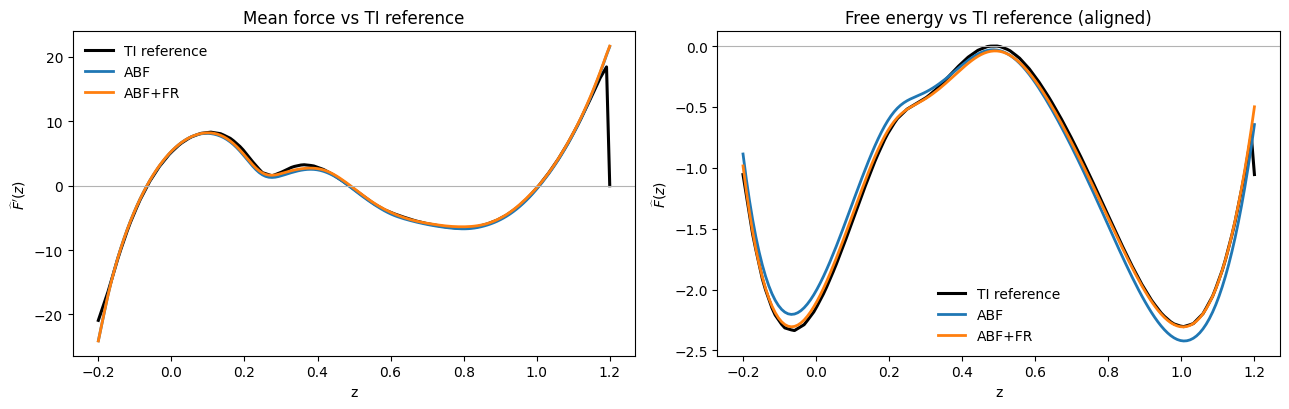

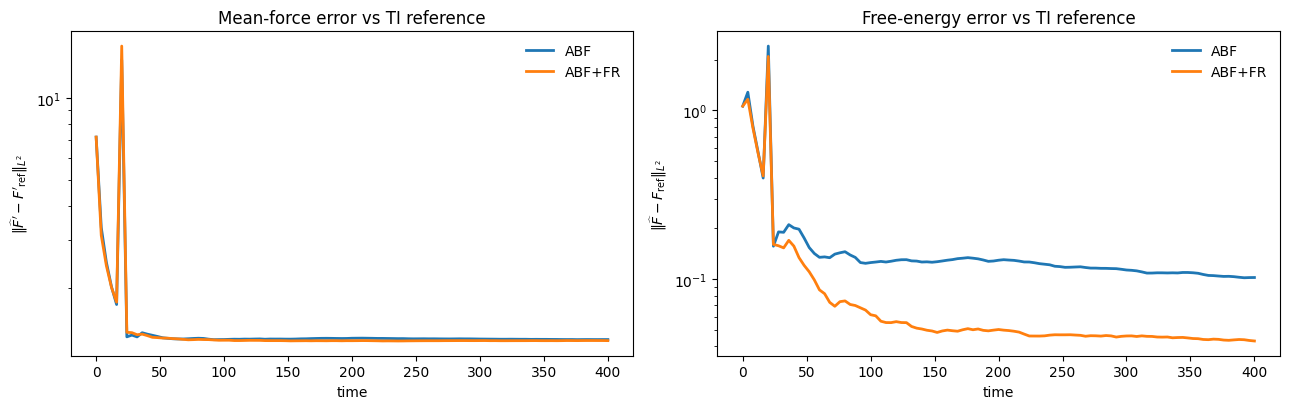

In [12]:
METHOD_ORDER = list(METHODS_TO_RUN)
METHOD_LABELS = {"abf": "ABF", "wfr_abf": "ABF+FR"}
METHOD_COLORS = {"abf": "tab:blue", "wfr_abf": "tab:orange"}


def estimated_profile_series(res):
    """ABF / ABF+FR report the adaptive mean-force estimate and its integral."""
    return res["mean_force"], res["pmf"]


def align_additive_constant_np(profile, reference, grid):
    """Free energy is defined up to a constant; align by the mean offset (gauge fix)."""
    profile = np.asarray(profile, dtype=float)
    reference = np.asarray(reference, dtype=float)
    return profile - np.mean(profile - reference)


def attach_reference_errors(results, reference):
    """Time-dependent L2 errors of F' and F (aligned) against the TI reference."""
    ref_grid = reference["grid"]
    for key, res in results.items():
        mf_series, fe_series = estimated_profile_series(res)
        res["l2_mean_force_ref"] = np.array([
            profile_l2_error_np(p, reference["mean_force"], ref_grid) for p in mf_series
        ])
        res["l2_free_energy_ref"] = np.array([
            profile_l2_error_np(
                align_additive_constant_np(p, reference["free_energy"], ref_grid),
                reference["free_energy"], ref_grid,
            )
            for p in fe_series
        ])


def summarize_results(results, reference):
    print(f"{'method':10s} {'L2 mean force':>14s} {'L2 free energy':>15s}")
    for key in METHOD_ORDER:
        res = results[key]
        print(f"{METHOD_LABELS[key]:10s} {res['l2_mean_force_ref'][-1]:14.4f} "
              f"{res['l2_free_energy_ref'][-1]:15.4f}")
    print("\nLower is better. Free energy aligned by an additive constant before the L2 error.")


def plot_profiles(results, reference):
    grid = reference["grid"]
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
    axes[0].plot(grid, reference["mean_force"], color="black", lw=2.2, label="TI reference")
    axes[1].plot(grid, reference["free_energy"], color="black", lw=2.2, label="TI reference")
    for key in METHOD_ORDER:
        res = results[key]
        g = res["grid"]
        mf, fe = estimated_profile_series(res)
        fe_al = align_additive_constant_np(fe[-1], reference["free_energy"], grid)
        axes[0].plot(g, mf[-1], color=METHOD_COLORS[key], lw=2, label=METHOD_LABELS[key])
        axes[1].plot(g, fe_al, color=METHOD_COLORS[key], lw=2, label=METHOD_LABELS[key])
    axes[0].axhline(0, color="0.7", lw=0.8)
    axes[1].axhline(0, color="0.7", lw=0.8)
    axes[0].set_title("Mean force vs TI reference")
    axes[0].set_xlabel("z"); axes[0].set_ylabel(r"$\widehat F'(z)$")
    axes[1].set_title("Free energy vs TI reference (aligned)")
    axes[1].set_xlabel("z"); axes[1].set_ylabel(r"$\widehat F(z)$")
    axes[0].legend(frameon=False); axes[1].legend(frameon=False)
    plt.tight_layout()
    plt.show()


def plot_l2_errors(results):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), sharex=True)
    for key in METHOD_ORDER:
        res = results[key]
        axes[0].plot(res["times"], res["l2_mean_force_ref"], color=METHOD_COLORS[key], lw=2, label=METHOD_LABELS[key])
        axes[1].plot(res["times"], res["l2_free_energy_ref"], color=METHOD_COLORS[key], lw=2, label=METHOD_LABELS[key])
    axes[0].set_title("Mean-force error vs TI reference")
    axes[0].set_xlabel("time"); axes[0].set_ylabel(r"$\|\widehat F' - F'_{\rm ref}\|_{L^2}$")
    axes[1].set_title("Free-energy error vs TI reference")
    axes[1].set_xlabel("time"); axes[1].set_ylabel(r"$\|\widehat F - F_{\rm ref}\|_{L^2}$")
    axes[0].set_yscale("log"); axes[1].set_yscale("log")
    axes[0].legend(frameon=False); axes[1].legend(frameon=False)
    plt.tight_layout()
    plt.show()


if results is not None and ti_reference is not None:
    attach_reference_errors(results, ti_reference)
    summarize_results(results, ti_reference)
    print("reference:", ti_reference["label"])
    plot_profiles(results, ti_reference)
    plot_l2_errors(results)
else:
    print("Run both the TI reference and the main simulation before plotting diagnostics.")

## Fisher--Rao hyperparameter sweep

Reuses the already-computed `ti_reference` and runs ABF+FR for each candidate FR
config from the **same** shared initial condition / seed, then ranks them by
free-energy accuracy (L2 of $\widehat F$ vs TI). A reduced-scale sweep on the
WCA dimer shows the free-energy benefit is **largest with gentle selection**
(`fr_rate ~ 0.2`, ~+48% vs ABF) and **decreases monotonically** as `fr_rate`
grows, because aggressive birth--death destroys the replica diversity the
mean-force estimator needs. The default `fr_rate=0.2` reflects this; the cell
below re-confirms it on the GPU and probes even gentler rates.

In [13]:
# ===================================================================
# Fisher-Rao hyperparameter sweep (run on the GPU after the main cells).
# Reuses the already-computed `ti_reference` and the ABF baseline in
# `results["abf"]`, then runs ABF+FR for each candidate FR config from the
# SAME shared initial condition / seed and ranks them by free-energy accuracy.
# ===================================================================
assert ti_reference is not None, "Run the TI reference cell first."
assert results is not None and "abf" in results, "Run the main simulation first."

# Sweep scale: a bit shorter than the headline run so the sweep is quick.
# Set SWEEP_FULL = True to sweep at the full production length.
SWEEP_FULL = False
sweep_sim = sim if SWEEP_FULL else replace(
    sim, n_steps=120_000, save_every=2000,
    abf_warmup_steps=10_000, estimator_burn_in_steps=10_000,
    fr_start_steps=20_000, marginal_burn_in_steps=20_000,
)

# FR candidates. fr_rate is the main lever (selection pressure ~ fr_rate * dt * fr_every).
FR_CANDIDATES = [
    dict(fr_rate=0.05, fr_every=5, score_clip=2.0),
    dict(fr_rate=0.1,  fr_every=5, score_clip=2.0),
    dict(fr_rate=0.2,  fr_every=5, score_clip=2.0),   # current default (gentle FR)
    dict(fr_rate=0.5,  fr_every=5, score_clip=2.0),
    dict(fr_rate=1.0,  fr_every=5, score_clip=2.0),
    dict(fr_rate=3.0,  fr_every=5, score_clip=2.0),
    dict(fr_rate=0.2,  fr_every=1, score_clip=2.0),
]

ref_grid = ti_reference["grid"]

def _sweep_errors(diag):
    mf, fe = diag["mean_force"][-1], diag["pmf"][-1]
    fe_al = align_additive_constant_np(fe, ti_reference["free_energy"], ref_grid)
    return (profile_l2_error_np(mf, ti_reference["mean_force"], ref_grid),
            profile_l2_error_np(fe_al, ti_reference["free_energy"], ref_grid))

# ABF baseline error (use a fresh ABF at the sweep scale for a fair comparison).
sweep_initial_q = lattice_initial_conditions(params, sweep_sim.n_replicas, engine.device, engine.dtype, seed=sweep_sim.seed)
abf_sweep = run_sampler_gpu("abf", params, sweep_sim, engine, initial_q=sweep_initial_q,
                            target_free_energy=None, verbose=False)
abf_fp, abf_f = _sweep_errors(abf_sweep)
print(f"ABF baseline @ sweep scale: L2 F'={abf_fp:.3f}  L2 F={abf_f:.3f}")

sweep_rows = []
for cfg in FR_CANDIDATES:
    simc = replace(sweep_sim, **cfg)
    d = run_sampler_gpu("wfr_abf", params, simc, engine, initial_q=sweep_initial_q,
                        target_free_energy=ti_reference["free_energy"], verbose=False)
    fp, f = _sweep_errors(d)
    sweep_rows.append(dict(cfg=cfg, l2_fp=fp, l2_f=f, repl=d["total_replacement_events"]))
    print(f"  rate={cfg['fr_rate']:<4} every={cfg['fr_every']} clip={cfg['score_clip']}: "
          f"L2 F'={fp:.3f} L2 F={f:.3f}  repl={d['total_replacement_events']:>7d}  "
          f"gainF={100*(abf_f-f)/abf_f:+5.1f}%  gainF'={100*(abf_fp-fp)/abf_fp:+5.1f}%")

print("\n=== ranked by L2 F (free-energy accuracy) ===")
print(f"{'fr_rate':>7} {'every':>5} {'clip':>4} {'L2 F':>7} {'L2 Fp':>7} {'gainF%':>7} {'repl':>8}")
print(f"{'ABF':>7} {'-':>5} {'-':>4} {abf_f:7.3f} {abf_fp:7.3f} {'-':>7} {'-':>8}")
for r in sorted(sweep_rows, key=lambda r: r["l2_f"]):
    c = r["cfg"]
    print(f"{c['fr_rate']:7} {c['fr_every']:5} {c['score_clip']:4} {r['l2_f']:7.3f} {r['l2_fp']:7.3f} "
          f"{100*(abf_f-r['l2_f'])/abf_f:+7.1f} {r['repl']:8d}")

ABF baseline @ sweep scale: L2 F'=1.302  L2 F=0.093
  rate=0.05 every=5 clip=2.0: L2 F'=1.284 L2 F=0.063  repl=    509  gainF=+32.4%  gainF'= +1.4%
  rate=0.1  every=5 clip=2.0: L2 F'=1.286 L2 F=0.053  repl=    989  gainF=+43.1%  gainF'= +1.2%
  rate=0.2  every=5 clip=2.0: L2 F'=1.291 L2 F=0.043  repl=   1721  gainF=+53.3%  gainF'= +0.9%
  rate=0.5  every=5 clip=2.0: L2 F'=1.293 L2 F=0.055  repl=   3315  gainF=+40.3%  gainF'= +0.7%
  rate=1.0  every=5 clip=2.0: L2 F'=1.295 L2 F=0.067  repl=   5775  gainF=+27.5%  gainF'= +0.6%
  rate=3.0  every=5 clip=2.0: L2 F'=1.306 L2 F=0.094  repl=  14918  gainF= -1.0%  gainF'= -0.2%
  rate=0.2  every=1 clip=2.0: L2 F'=1.295 L2 F=0.046  repl=   1621  gainF=+50.1%  gainF'= +0.5%

=== ranked by L2 F (free-energy accuracy) ===
fr_rate every clip    L2 F   L2 Fp  gainF%     repl
    ABF     -    -   0.093   1.302       -        -
    0.2     5  2.0   0.043   1.291   +53.3     1721
    0.2     1  2.0   0.046   1.295   +50.1     1621
    0.1     5  2.0   